# IEMS 490 Predict Anomalies

In [21]:
import torch
from torch_fn.wavenet_lstm import lr_schedule, WaveNet_LSTM #LSTM of WaveNet
from torch_fn.wavenet2 import WaveNet # Normal WaveNet, likely from the paper. Need someone who is literate to check.
import h5py
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
# Load the data from the .npz file
npz_file = np.load('my_arrays.npz')

# Access individual arrays
median_lazer = npz_file['arr_a']
median_signal = npz_file['arr_b']

# Optional: check the names of all arrays in the file
print(f"Arrays in file: {npz_file.files}")

# Close the NpzFile object
npz_file.close()


Arrays in file: ['arr_a', 'arr_b']


In [3]:
npz_file = np.load('val_arrays.npz')
bulk, overhang, c1, c2 = npz_file['a'], npz_file['b'], npz_file['c'], npz_file['d']

In [14]:
# 1. Combine lists into a single NumPy array (Shape: N x 2)
# This is significantly faster than a list comprehension for large data
all_data = np.stack([median_lazer, median_signal], axis=1)
all_stats = np.stack([bulk, overhang, c1, c2], axis = 1)
# 2. Split the NumPy array directly
train_x, test_x, train_y, test_y = train_test_split(all_data, all_stats, test_size=0.6, shuffle=False, random_state=67) # Sik Sewen

# 3. Convert directly to Tensors
# .float() ensures they are float32, which most PyTorch models expect
x_train_tensor = torch.from_numpy(train_x).float()
x_test_tensor  = torch.from_numpy(test_x).float()
y_train_tensor = torch.from_numpy(train_y).float()
y_test_tensor = torch.from_numpy(test_y).float()
print(f"Train Tensor Shape: {x_train_tensor.shape}")
print(f"Test Tensor Shape:  {x_test_tensor.shape}")

# 4. Create Dataset and Loader
# Using (x, x) for Autoencoder style or self-supervised training
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train Tensor Shape: torch.Size([151, 2, 8836])
Test Tensor Shape:  torch.Size([228, 2, 8836])


In [ ]:
class net3(nn.Module):
    def __init__(self, input_channels, nodes_per_channel, output_channels):
        super(net3, self).__init__()
        # input_channels=2, nodes_per_channel=32 -> total_nodes=64
        total_nodes = nodes_per_channel * input_channels
        
        self.hidden = nn.Conv1d(input_channels, total_nodes, kernel_size=1, groups=input_channels)
        self.output = nn.Conv1d(total_nodes, output_channels, kernel_size=1) # No groups here if you want channels to merge
        self.activation = nn.Tanh()

    def forward(self, x):
        # x: [Batch, 2, 8836]
        x = self.hidden(x)      
        x = self.activation(x)
        x = self.output(x)      
        return torch.sigmoid(x) # USE THE FUNCTION, NOT THE CLASS

In [17]:
# make the model, this will be the model for all of MCE
class net3(nn.Module):
    def __init__(self, input_channels, nodes, output_channels):
        super(net3, self).__init__()
        # Conv1d with kernel_size=1 acts like a Linear layer on each point
        total_nodes = nodes * input_channels
        
        self.hidden = nn.Conv1d(input_channels, total_nodes, kernel_size=1, groups=input_channels)
        self.output = nn.Conv1d(total_nodes, output_channels, kernel_size=1, groups=input_channels)
        self.activation = nn.Tanh()

    def forward(self, x):
        # x input: [Batch, 2, 8836]
        output = self.hidden(x)     # [Batch, nodes, 8836]
        output = self.activation(output)
        output = self.output(output) # [Batch, 2, 8836]
        output = nn.Sigmoid(output)
        return output
    
def train(dataloader, model, loss_func, optimizer):
  model.train()
  train_loss = []
  
  for batch, (X, y) in enumerate(dataloader):
    if X.shape[1] != 2: 
        X = X.permute(0, 2, 1)

    pred = model(X.float()) 
    # Ensure target y is same shape as pred [Batch, 1, 8836]
    if y.dim() == 2:
        y = y.unsqueeze(1)
        
    loss = loss_func(pred, y.float()) # Ensure both are float32

    # where the magic happens
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 10 == 0:
      loss, current = loss.item(), batch * len(X)
      train_loss.append(loss)
  return train_loss

def test(dataloader, model, loss_func):
  num_batches = 170
  model.eval()
  test_loss = 0
  correct = 0
  total = 0
  m = nn.Softmax(dim=0)

  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_func(pred, y.squeeze()).item()
      pred = m(pred)
      predicted_labels = int(pred[1] > pred[0])
      correct += (predicted_labels == y).sum().item()
      total += y.size(0)
  test_loss /= num_batches
  accuracy = correct / total
  print(f"Test Error: \n Accuracy: {(100 * accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
  return test_loss

In [20]:
model = net3(2,32,1)
train(train_loader, model, loss_func=nn.BCELoss(), optimizer=torch.optim.Adam(params=model.parameters(), lr=1e-3))

ValueError: Using a target size (torch.Size([32, 1, 4])) that is different to the input size (torch.Size([32, 1, 8836])) is deprecated. Please ensure they have the same size.

#### Model that might work

In [29]:
class Net3_MultiHead(nn.Module):
    def __init__(self, input_channels, nodes_per_channel, seq_len=8836):
        super(Net3_MultiHead, self).__init__()
        
        # 1. Feature Extraction (The WaveNet/Conv part)
        self.conv1 = nn.Conv1d(input_channels, nodes_per_channel * 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(nodes_per_channel * 2, nodes_per_channel, kernel_size=1)
        self.activation = nn.Tanh()
        self.flatten = nn.Flatten()
        
        # 2. The Shared "Brain" (Bottleneck)
        # 32 nodes * 8836 length = 282,752 inputs
        self.fc_shared = nn.Linear(nodes_per_channel * seq_len, 128)
        
        # 3. The Four Specific Heads
        self.head_binary1 = nn.Linear(128, 1)  # Binary 1
        self.head_binary2 = nn.Linear(128, 1)  # Binary 2
        self.head_val0_9  = nn.Linear(128, 1)  # Range 0-9
        self.head_val0_20 = nn.Linear(128, 1)  # Range 0-20

    def forward(self, x):
        # x: [Batch, 2, 8836]
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.flatten(x)
        x = self.activation(self.fc_shared(x))
        
        # Branching out
        # We use Sigmoid for binaries and ReLU/None for the ranges
        b1 = torch.sigmoid(self.head_binary1(x))
        b2 = torch.sigmoid(self.head_binary2(x))
        
        # Use ReLU to ensure values are at least 0
        v1 = F.relu(self.head_val0_9(x))
        v2 = F.relu(self.head_val0_20(x))
        
        # Concatenate them back into [Batch, 4]
        return torch.cat([b1, b2, v1, v2], dim=1)

In [34]:
class Net3_MultiHead(nn.Module):
    def __init__(self, input_channels, nodes_per_channel, seq_len=8836):
        super(Net3_MultiHead, self).__init__()
        self.conv = nn.Conv1d(input_channels, nodes_per_channel, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        # The 128 is a hidden bottleneck before splitting to 4 outputs
        self.fc = nn.Linear(nodes_per_channel * seq_len, 128)
        self.head = nn.Linear(128, 4) 

    def forward(self, x):
        x = F.tanh(self.conv(x))
        x = self.flatten(x)
        x = F.tanh(self.fc(x))
        x = self.head(x)
        
        # We handle the activations (sigmoid for first two) inside the loss
        # or right here:
        out = x.clone()
        out[:, :2] = torch.sigmoid(x[:, :2]) 
        return out

In [35]:
# In your training call:
model = Net3_MultiHead(2, 32)
loss_func = nn.MSELoss() # MSE works for both binaries and ranges

In [ ]:
def train(dataloader, model, loss_func, optimizer):
    model.train()
    train_loss = []
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.float(), y.float()
        
        # 1. Correct Input Shape: [Batch, 2, 8836]
        if X.shape[1] != 2: 
            X = X.permute(0, 2, 1)

        # 2. Forward pass: pred should be [Batch, 4]
        pred = model(X) 
        
        # 3. Ensure y is [Batch, 4]. No unsqueeze!
        if y.dim() == 3: # If it's accidentally [Batch, 1, 4]
            y = y.squeeze(1)

        # 4. Split Loss Calculation
        # Binary Cross Entropy for columns 0 and 1
        loss_b = F.binary_cross_entropy(pred[:, :1], y[:, :1])
        # Mean Squared Error for columns 2 and 3
        loss_r = F.mse_loss(pred[:, 1:], y[:, 1:])
        
        loss = loss_b + loss_r

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 10 == 0:
            print(f"Batch {batch}, Loss: {loss.item():.4f}")
            train_loss.append(loss.item())
            
    return train_loss

def test(dataloader, model):
    model.eval()
    total_mse = 0
    binary_correct = 0
    total_count = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.float(), y.float()
            if X.shape[1] != 2: X = X.permute(0, 2, 1)
            if y.dim() == 3: y = y.squeeze(1)

            pred = model(X)
            
            # Accuracy for the two binary heads
            preds_binary = (pred[:, :1] > 0.5).float()
            binary_correct += (preds_binary == y[:, :1]).sum().item()
            
            # Error for the two value heads
            total_mse += F.mse_loss(pred[:, 1:], y[:, 1:]).item()
            
            total_count += y.size(0)

    avg_acc = (binary_correct / (total_count * 2)) * 100
    avg_mse = total_mse / len(dataloader)
    print(f"Test Results:\n Binary Accuracy: {avg_acc:.2f}%\n Regression MSE: {avg_mse:.4f}")
    return avg_mse

In [46]:
torch.manual_seed(67) # Sick Sewennn
model = Net3_MultiHead(2, 32)
loss_func = nn.MSELoss() # MSE works for both binaries and ranges
epochs = 20
train_losses = []
test_losses = []
for epoch in range(epochs):
    train_loss = train(train_loader, model, loss_func=loss_func, optimizer=torch.optim.Adam(params=model.parameters(), lr=1e-3))
    train_losses.append(train_loss)
    test_loss = test(test_loader, model)
    test_losses.append(test_loss)

Batch 0, Loss: 144.1281
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 209.5100
Batch 0, Loss: 86.8638
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 204.0481
Batch 0, Loss: 228.8755
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 199.2843
Batch 0, Loss: 161.9667
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 194.8658
Batch 0, Loss: 109.8443
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 191.5292
Batch 0, Loss: 119.9861
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 188.1465
Batch 0, Loss: 249.2133
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 185.1274
Batch 0, Loss: 148.8843
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 182.3019
Batch 0, Loss: 192.9229
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 179.9429
Batch 0, Loss: 32.8706
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 178.3086
Batch 0, Loss: 48.0744
Test Results:
 Binary Accuracy: 38.82%
 Regression MSE: 176.8600
Batch 0, Loss: 106.6463


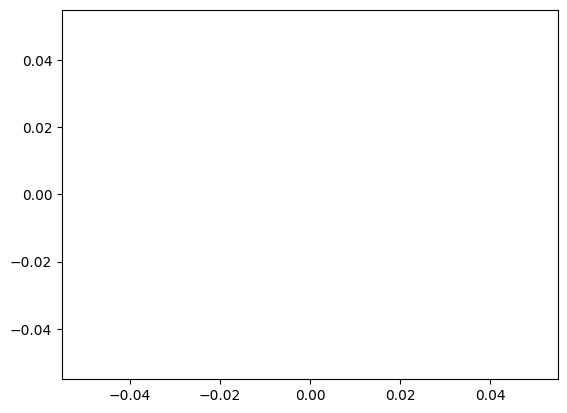

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.plot(test_losses)
plt.show()

In [48]:
def test(dataloader, model):
    model.eval()
    total_mse = 0
    binary_correct = 0
    total_count = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.float(), y.float()
            if X.shape[1] != 2: X = X.permute(0, 2, 1)
            if y.dim() == 3: y = y.squeeze(1)

            pred = model(X)
            
            # Accuracy for the two binary heads
            preds_binary = 0
            binary_correct += (preds_binary == y[:, :1]).sum().item()
            
            # Error for the two value heads
            total_mse += F.mse_loss(pred[:, 1:], y[:, 1:]).item()
            
            total_count += y.size(0)

    avg_acc = (binary_correct / (total_count * 2)) * 100
    avg_mse = total_mse / len(dataloader)
    print(f"Test Results:\n Binary Accuracy: {avg_acc:.2f}%\n Regression MSE: {avg_mse:.4f}")
    return avg_mse
test_loss = test(test_loader, model)

Test Results:
 Binary Accuracy: 11.18%
 Regression MSE: 171.9782
